# COSDUO - Stage 1 EDA Final
**y_labels_final.csv 기반 탐색적 데이터 분석**

담당: 최여정

### 목차
- Part 1: 데이터셋 구성 요약
- Part 2: skin 858명 Y값 분석
- Part 3: disease 1800명 Y값 분석
- Part 4: 전체 2658명 Y값 비교
- Part 5: 캐글 데이터와 비교
- Part 6: 최종 인사이트 요약

In [1]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from google.colab import drive
drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/캡스톤_선호, 여정/test_data/AI-HUB 데이터'
LABEL_DIR = BASE + '/labels'
EDA_DIR   = BASE + '/eda_results_final'
OTHER_DIR = BASE + '/aihub_skin/Other/메타데이터'
os.makedirs(EDA_DIR, exist_ok=True)

# 데이터 로드
df         = pd.read_csv(LABEL_DIR + '/y_labels_final.csv')
skin_df    = df[df['data_source'] == 'aihub_skin'].copy()
disease_df = df[df['data_source'] == 'aihub_disease'].copy()

skin_df['gender_label'] = skin_df['gender'].map({0.0: '남성', 1.0: '여성'})
skin_df['age_group']    = pd.cut(skin_df['age'],
                                  bins=[0,29,39,49,59,100],
                                  labels=['20대','30대','40대','50대','60대+'])

Y_COLS  = ['Acne_Severity','Dryness_Severity','Aging_Severity',
           'Pigmentation_Severity','Sensitivity_Severity']
COLORS  = {
    'Acne_Severity'        : '#E74C3C',
    'Dryness_Severity'     : '#3498DB',
    'Aging_Severity'       : '#2ECC71',
    'Pigmentation_Severity': '#F39C12',
    'Sensitivity_Severity' : '#9B59B6',
}

print(f'전체: {len(df)}개')
print(f'  - aihub_skin   : {len(skin_df)}개')
print(f'  - aihub_disease: {len(disease_df)}개')
print(f'\n결측값:')
print(df[Y_COLS].isnull().sum())

Mounted at /content/drive
전체: 2658개
  - aihub_skin   : 858개
  - aihub_disease: 1800개

결측값:
Acne_Severity            0
Dryness_Severity         0
Aging_Severity           0
Pigmentation_Severity    0
Sensitivity_Severity     0
dtype: int64


---
## Part 1. 데이터셋 구성 요약

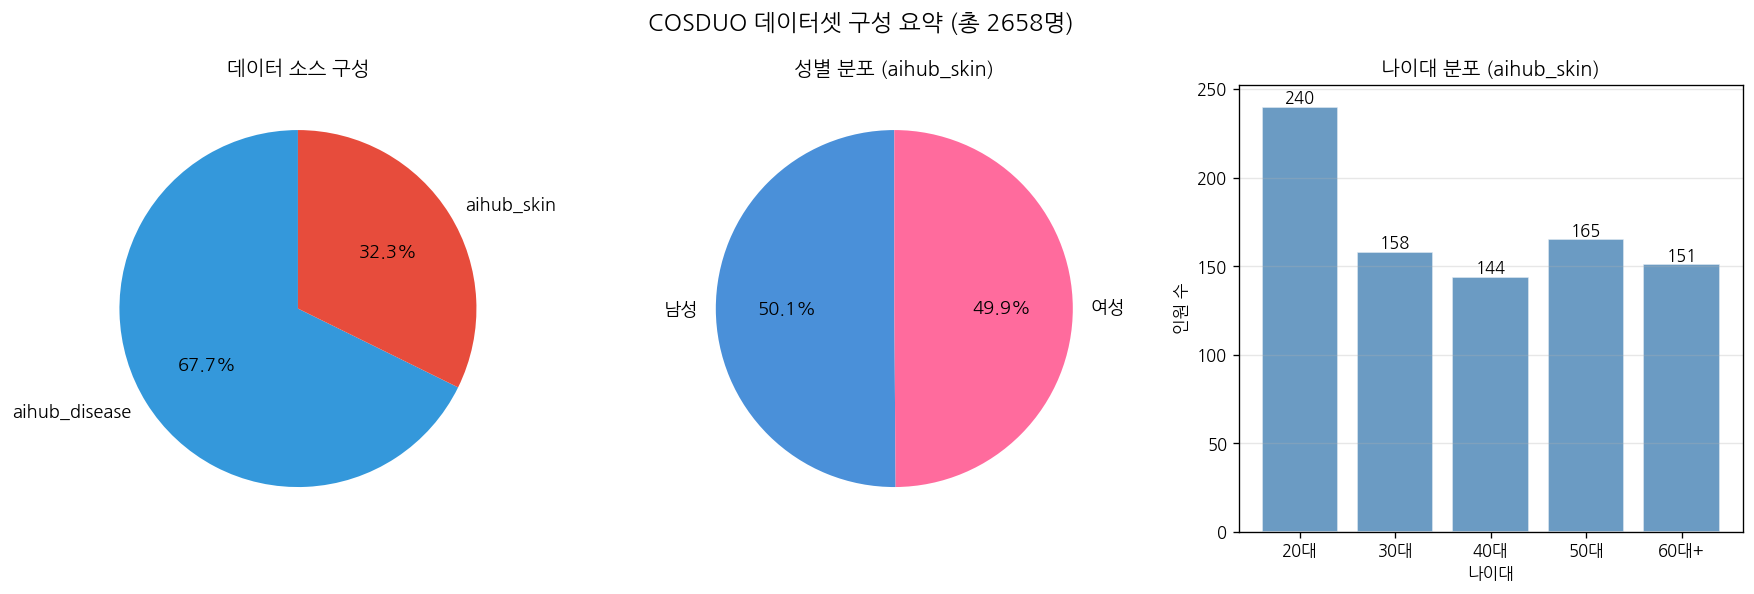

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 데이터 소스 비율
source_counts = df['data_source'].value_counts()
axes[0].pie(source_counts.values, labels=source_counts.index,
            colors=['#3498DB','#E74C3C'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('데이터 소스 구성', fontsize=12, fontweight='bold')

# 성별 분포 (skin)
gender_counts = skin_df['gender_label'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            colors=['#4A90D9','#FF6B9D'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('성별 분포 (aihub_skin)', fontsize=12, fontweight='bold')

# 나이대 분포 (skin)
age_counts = skin_df['age_group'].value_counts().sort_index()
bars = axes[2].bar(age_counts.index, age_counts.values,
                   color='steelblue', alpha=0.8, edgecolor='white')
for bar, val in zip(bars, age_counts.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(val), ha='center', fontsize=10)
axes[2].set_title('나이대 분포 (aihub_skin)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('나이대'); axes[2].set_ylabel('인원 수')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('COSDUO 데이터셋 구성 요약 (총 2658명)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/01_dataset_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2. skin 858명 Y값 분석

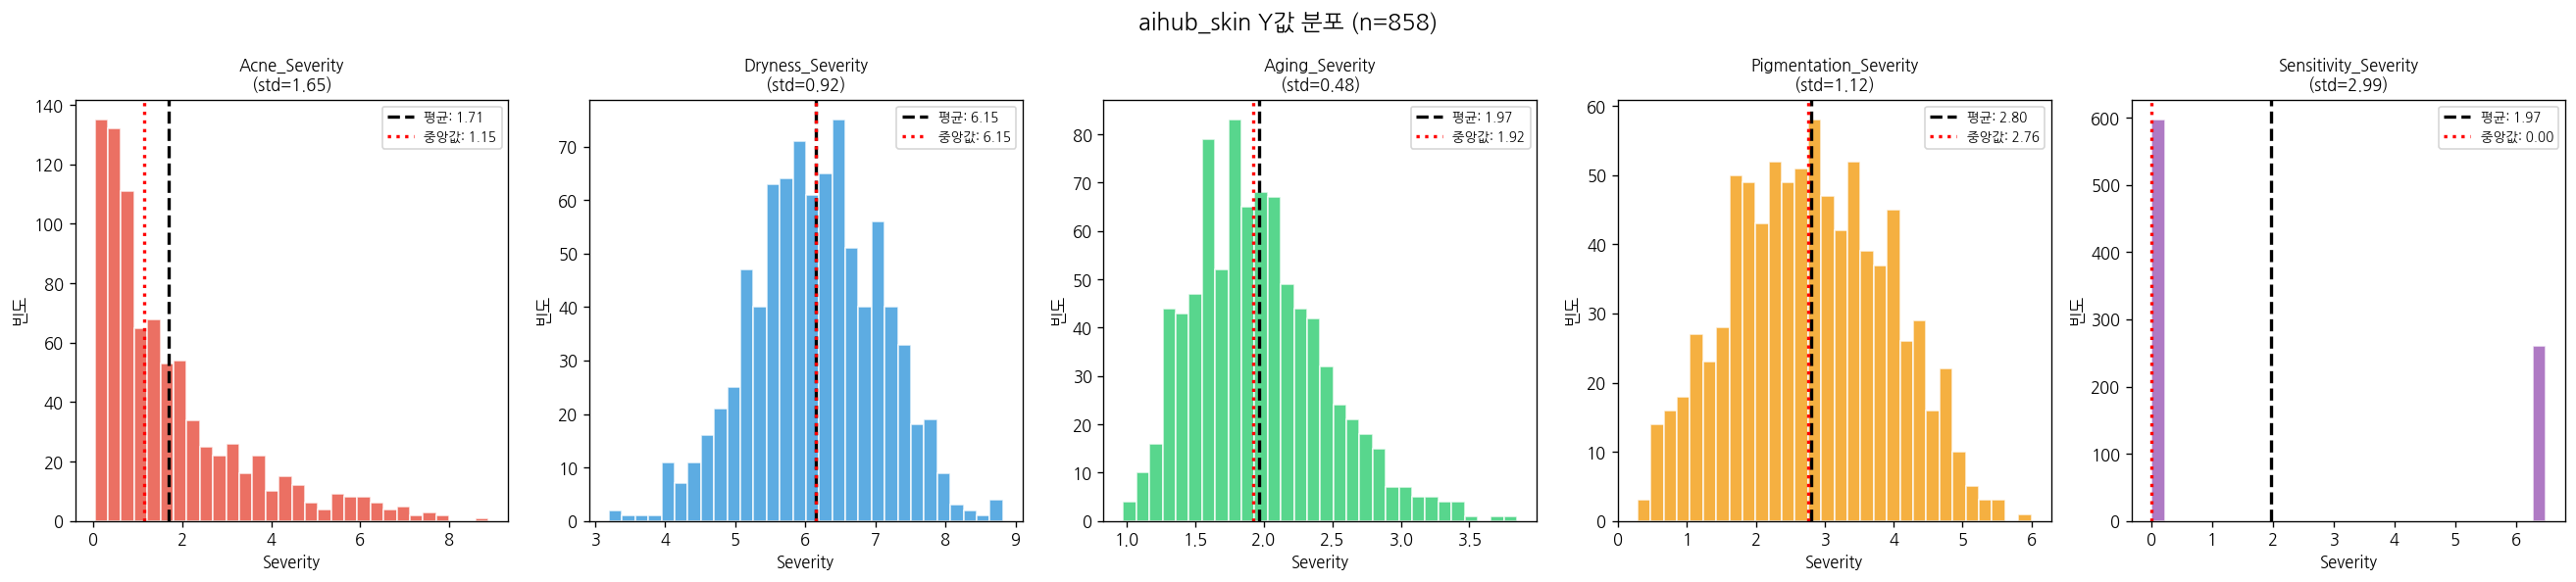

In [3]:
# 2-1. Y값 분포 히스토그램
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(Y_COLS):
    data = skin_df[col].dropna()
    axes[i].hist(data, bins=30, color=COLORS[col], alpha=0.8, edgecolor='white')
    axes[i].axvline(data.mean(),   color='black', linestyle='--', linewidth=2,
                    label=f'평균: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='red',   linestyle=':',  linewidth=2,
                    label=f'중앙값: {data.median():.2f}')
    axes[i].set_title(f'{col}\n(std={data.std():.2f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Severity'); axes[i].set_ylabel('빈도')
    axes[i].legend(fontsize=8)

plt.suptitle('aihub_skin Y값 분포 (n=858)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/02_skin_y_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7198/1159170069.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=Y_COLS, patch_artist=True,


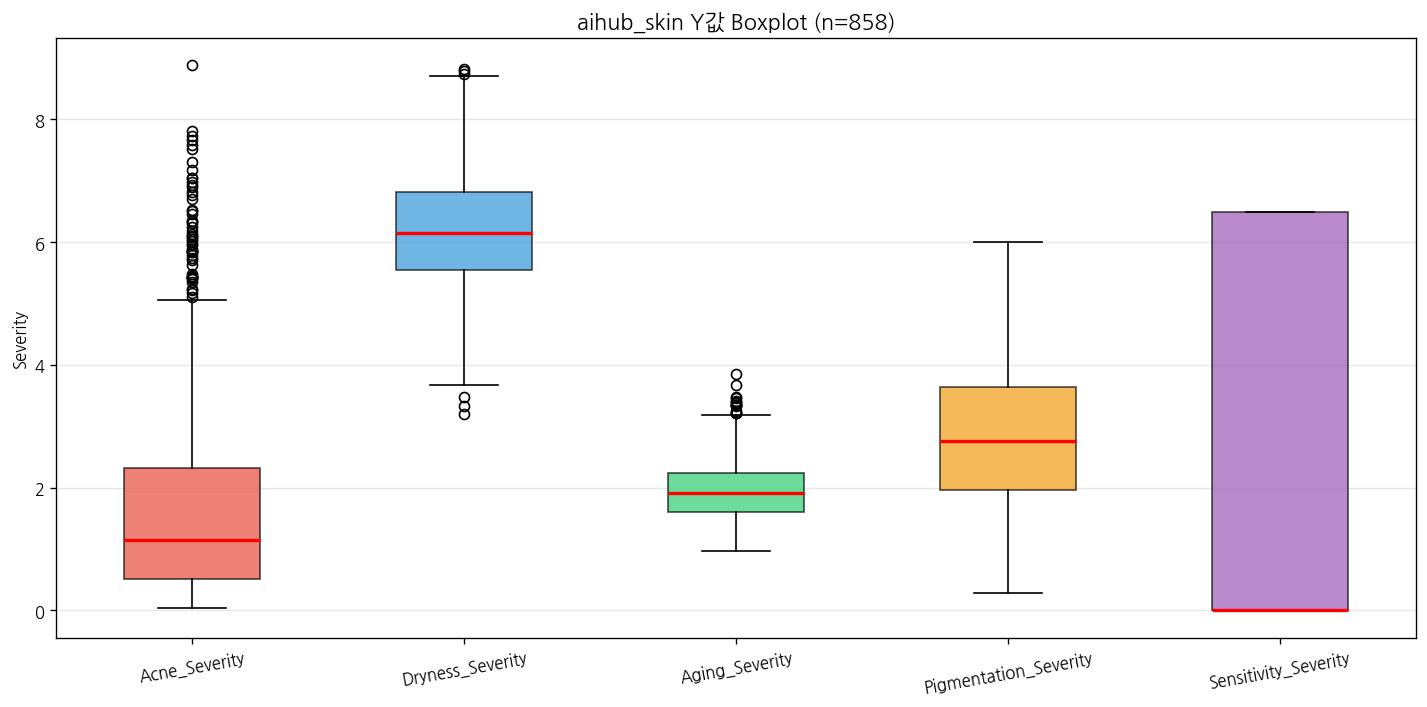

In [4]:
# 2-2. Y값 Boxplot
fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = [skin_df[col].dropna().values for col in Y_COLS]
bp = ax.boxplot(data_to_plot, labels=Y_COLS, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch, col in zip(bp['boxes'], Y_COLS):
    patch.set_facecolor(COLORS[col]); patch.set_alpha(0.7)
ax.set_title('aihub_skin Y값 Boxplot (n=858)', fontsize=13, fontweight='bold')
ax.set_ylabel('Severity'); ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_DIR + '/03_skin_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

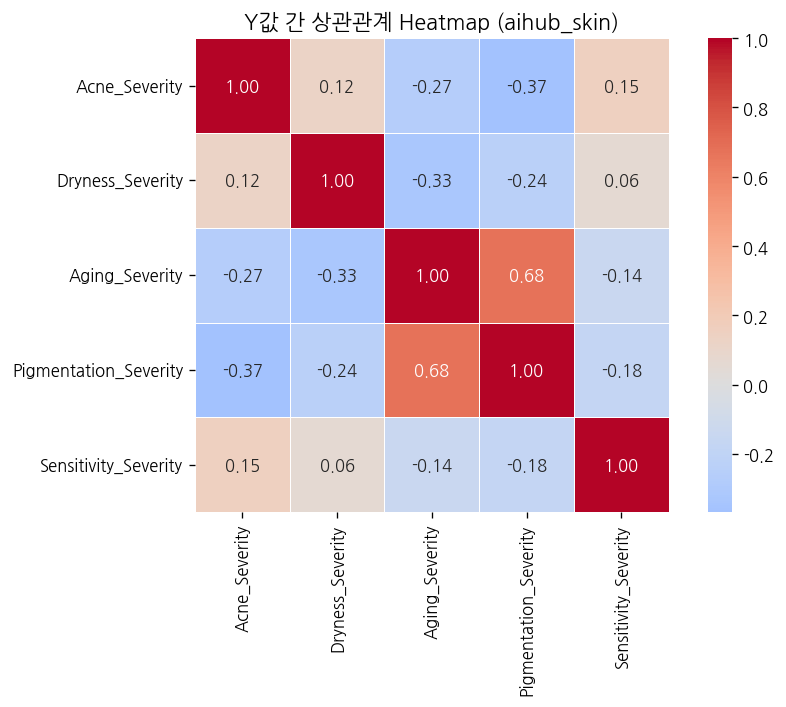

Aging-Pigmentation r=0.68


In [5]:
# 2-3. 상관관계 Heatmap (skin)
fig, ax = plt.subplots(figsize=(8, 6))
corr = skin_df[Y_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 10}, square=True)
ax.set_title('Y값 간 상관관계 Heatmap (aihub_skin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/04_skin_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Aging-Pigmentation r={corr.loc["Aging_Severity","Pigmentation_Severity"]:.2f}')

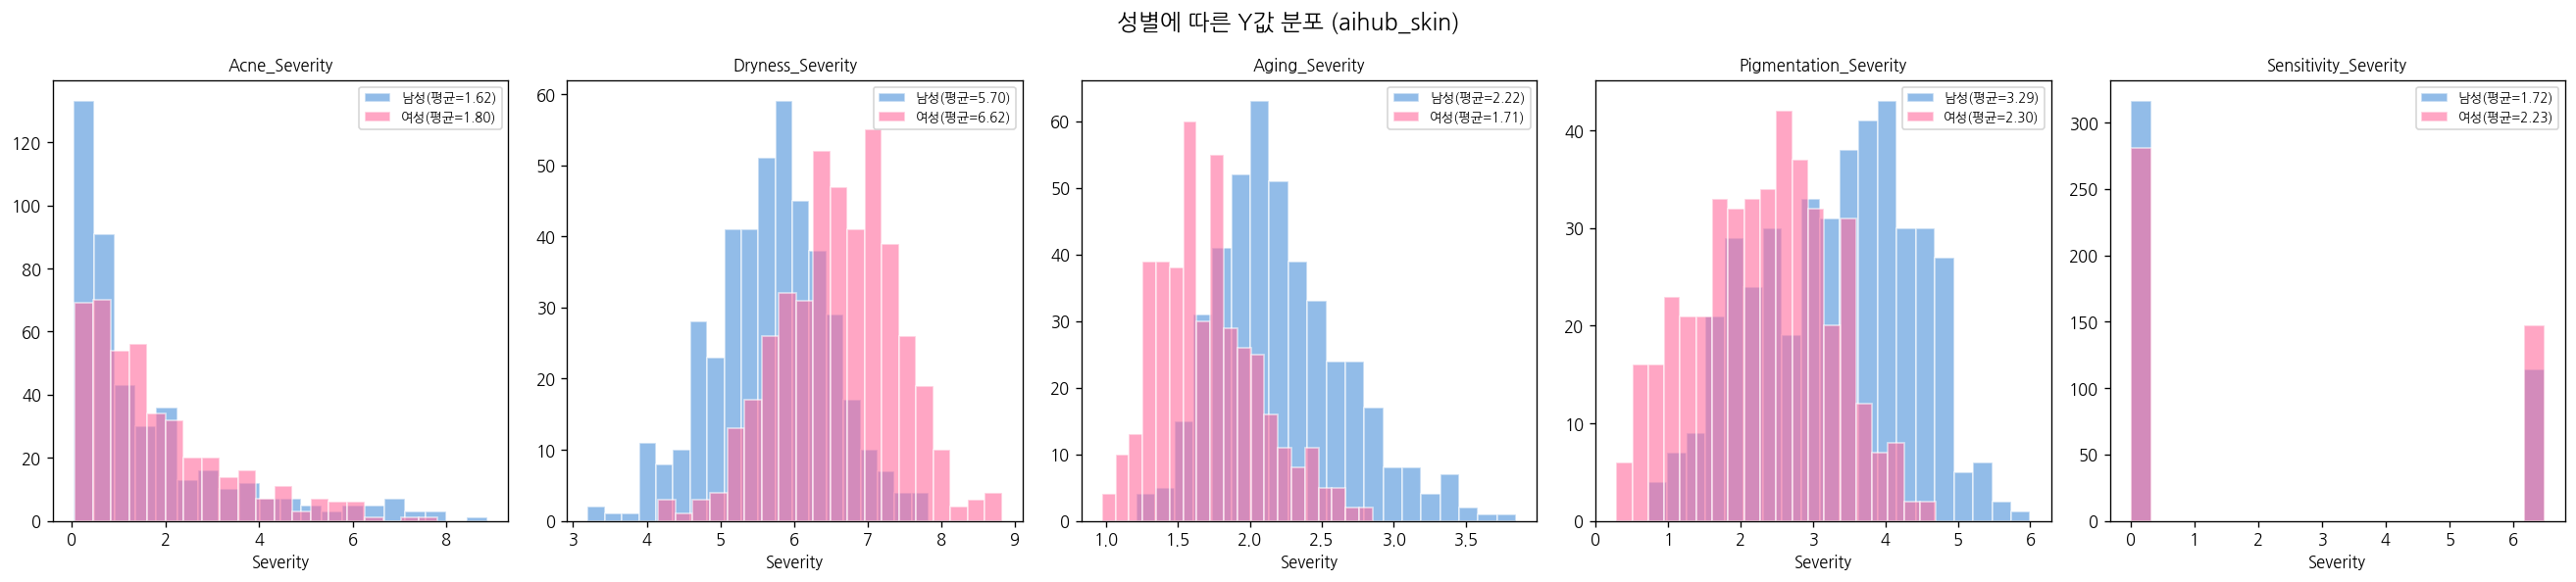

              Acne_Severity  Dryness_Severity  Aging_Severity  \
gender_label                                                    
남성                     1.62              5.70            2.22   
여성                     1.80              6.62            1.71   

              Pigmentation_Severity  Sensitivity_Severity  
gender_label                                               
남성                             3.29                  1.72  
여성                             2.30                  2.23  


In [6]:
# 2-4. 성별 비교
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(Y_COLS):
    for gender, color in [('남성','#4A90D9'),('여성','#FF6B9D')]:
        data = skin_df[skin_df['gender_label']==gender][col].dropna()
        axes[i].hist(data, bins=20, alpha=0.6, color=color,
                     label=f'{gender}(평균={data.mean():.2f})', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8); axes[i].set_xlabel('Severity')
plt.suptitle('성별에 따른 Y값 분포 (aihub_skin)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/05_skin_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print(skin_df.groupby('gender_label')[Y_COLS].mean().round(2))

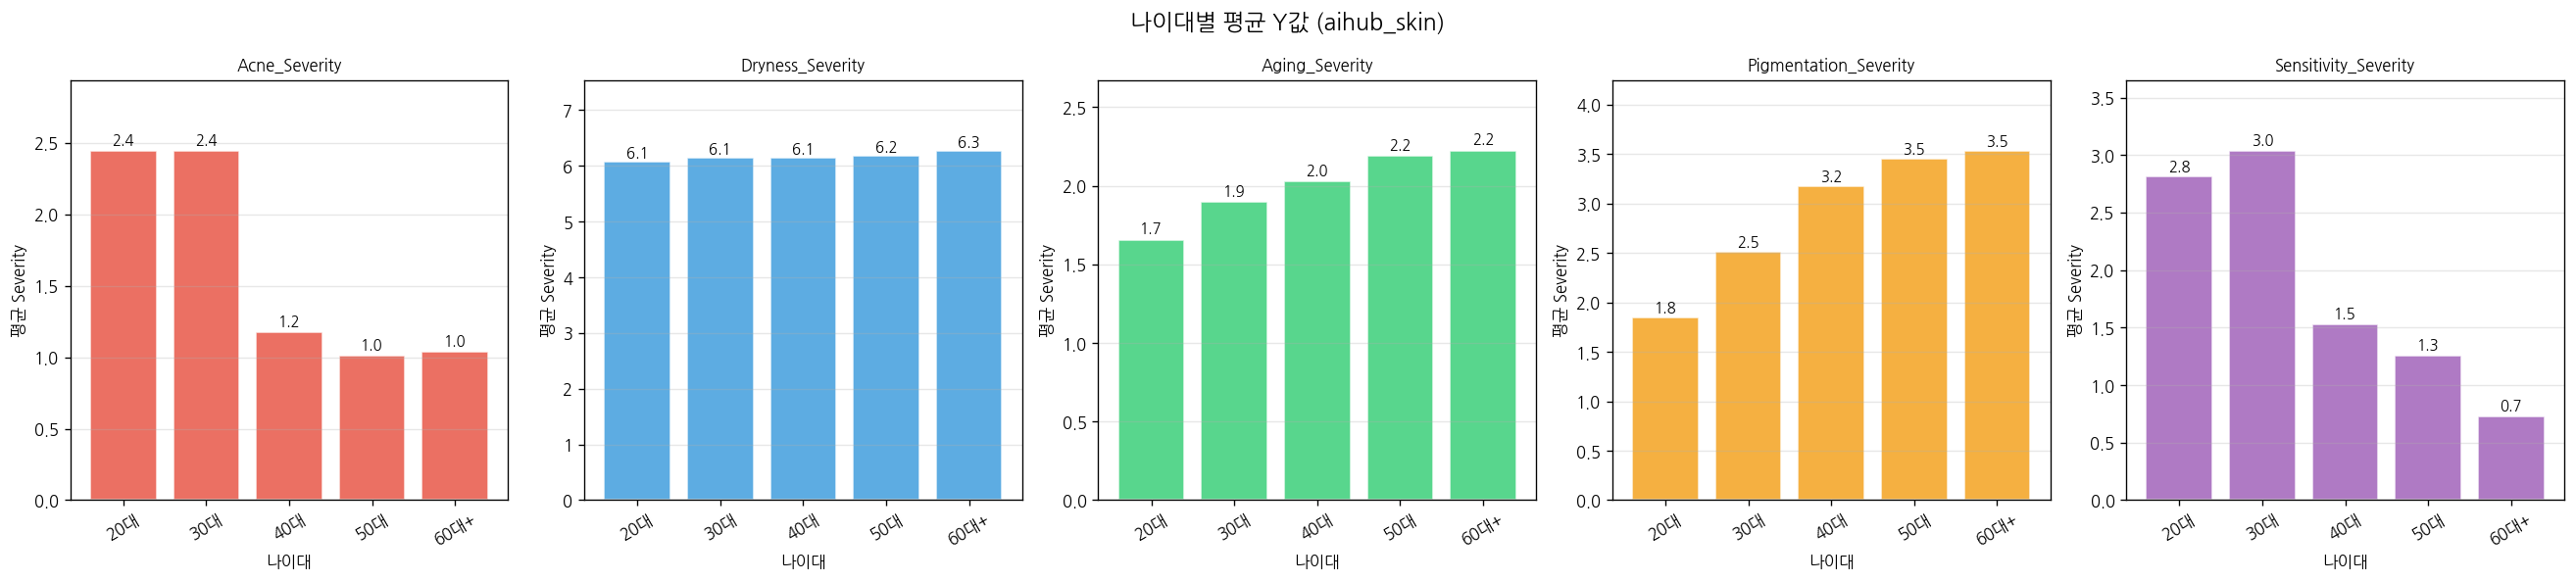

In [7]:
# 2-5. 나이대별 평균 Y값
age_mean = skin_df.groupby('age_group', observed=False)[Y_COLS].mean()
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(Y_COLS):
    bars = axes[i].bar(age_mean.index, age_mean[col],
                       color=COLORS[col], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, age_mean[col]):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('나이대'); axes[i].set_ylabel('평균 Severity')
    axes[i].set_ylim(0, age_mean[col].max()*1.2)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('나이대별 평균 Y값 (aihub_skin)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/06_skin_age.png', dpi=150, bbox_inches='tight')
plt.show()

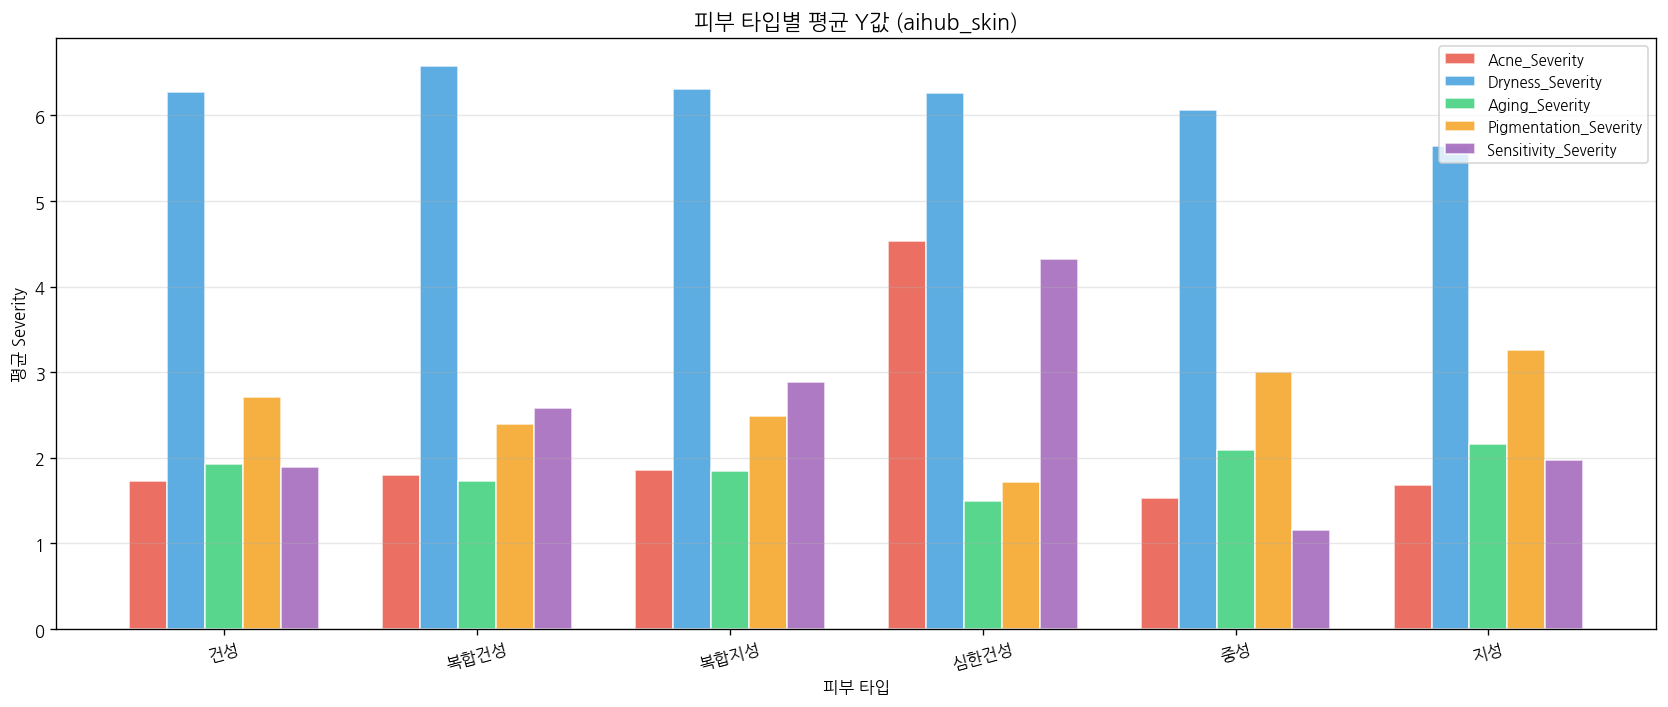

In [8]:
# 2-6. 피부 타입별 Y값
meta = pd.read_csv(OTHER_DIR + '/meta_data.csv')
meta['image_id'] = meta['subject_no'].astype(str)
skin_df2 = skin_df.copy()
skin_df2['image_id'] = skin_df2['image_id'].astype(str)
skin_with_type = skin_df2.merge(meta[['image_id','얼굴피부타입']], on='image_id', how='left')
type_mean = skin_with_type.groupby('얼굴피부타입')[Y_COLS].mean()

fig, ax = plt.subplots(figsize=(14, 6))
x, width = np.arange(len(type_mean.index)), 0.15
for j, col in enumerate(Y_COLS):
    ax.bar(x+j*width, type_mean[col], width, label=col,
           color=list(COLORS.values())[j], alpha=0.8, edgecolor='white')
ax.set_xlabel('피부 타입'); ax.set_ylabel('평균 Severity')
ax.set_title('피부 타입별 평균 Y값 (aihub_skin)', fontsize=13, fontweight='bold')
ax.set_xticks(x+width*2); ax.set_xticklabels(type_mean.index, rotation=15)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_DIR + '/07_skin_skintype.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3. disease 1800명 Y값 분석

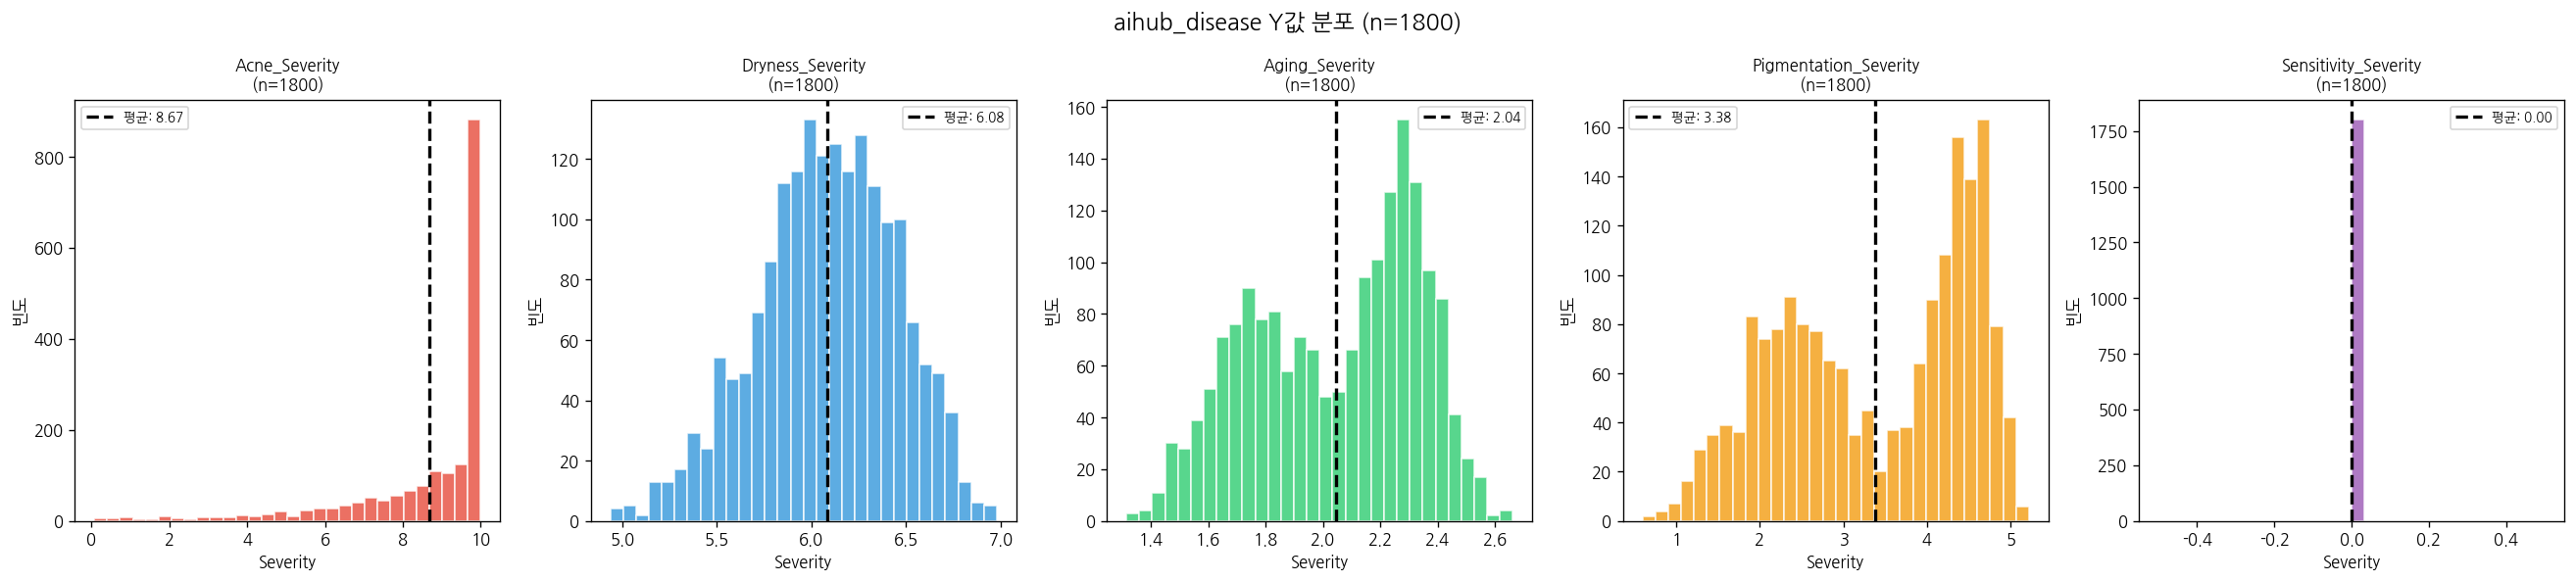

In [9]:
# 3-1. Y값 분포
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(Y_COLS):
    data = disease_df[col].dropna()
    axes[i].hist(data, bins=30, color=COLORS[col], alpha=0.8, edgecolor='white')
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=2,
                    label=f'평균: {data.mean():.2f}')
    axes[i].set_title(f'{col}\n(n={len(data)})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Severity'); axes[i].set_ylabel('빈도')
    axes[i].legend(fontsize=8)
plt.suptitle('aihub_disease Y값 분포 (n=1800)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/08_disease_y_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

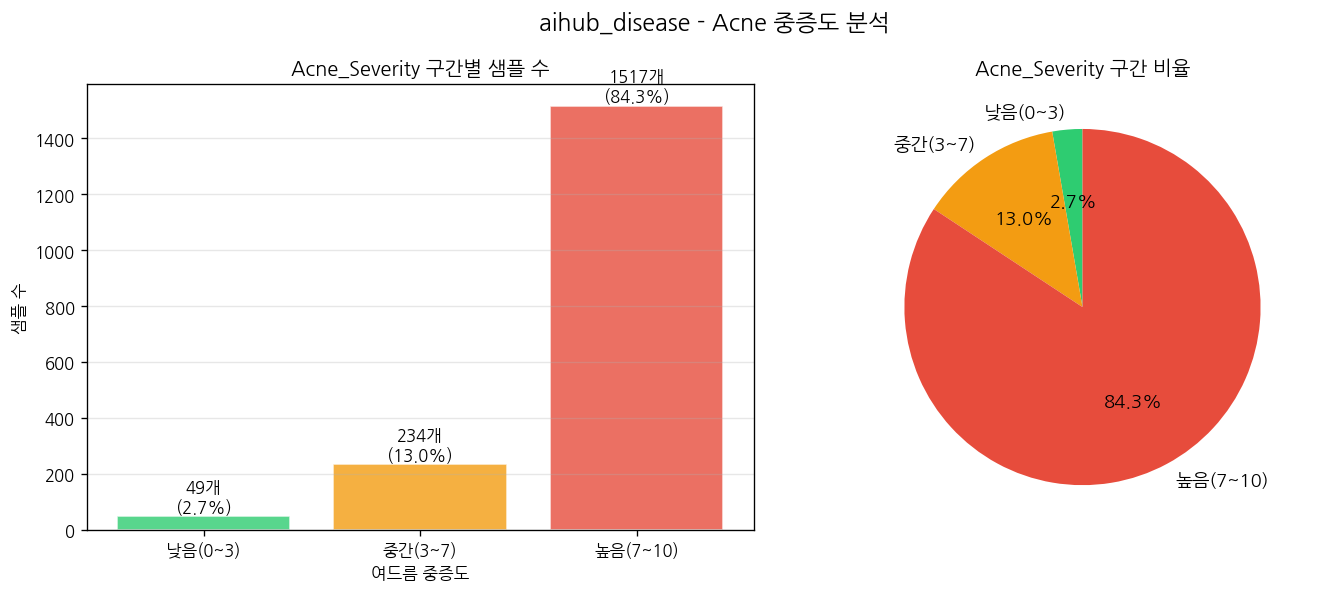

In [10]:
# 3-2. Acne 구간별 분포
disease_df2 = disease_df.copy()
disease_df2['acne_level'] = pd.cut(disease_df2['Acne_Severity'],
                                    bins=[-0.1, 3, 7, 10],
                                    labels=['낮음(0~3)','중간(3~7)','높음(7~10)'])
acne_counts = disease_df2['acne_level'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_level = ['#2ECC71','#F39C12','#E74C3C']
bars = axes[0].bar(acne_counts.index, acne_counts.values,
                   color=colors_level, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, acne_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val}개\n({val/len(disease_df2)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Acne_Severity 구간별 샘플 수', fontsize=12, fontweight='bold')
axes[0].set_xlabel('여드름 중증도'); axes[0].set_ylabel('샘플 수')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(acne_counts.values, labels=acne_counts.index,
            colors=colors_level, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Acne_Severity 구간 비율', fontsize=12, fontweight='bold')
plt.suptitle('aihub_disease - Acne 중증도 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/09_disease_acne_level.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4. 전체 2658명 Y값 비교 (skin vs disease)

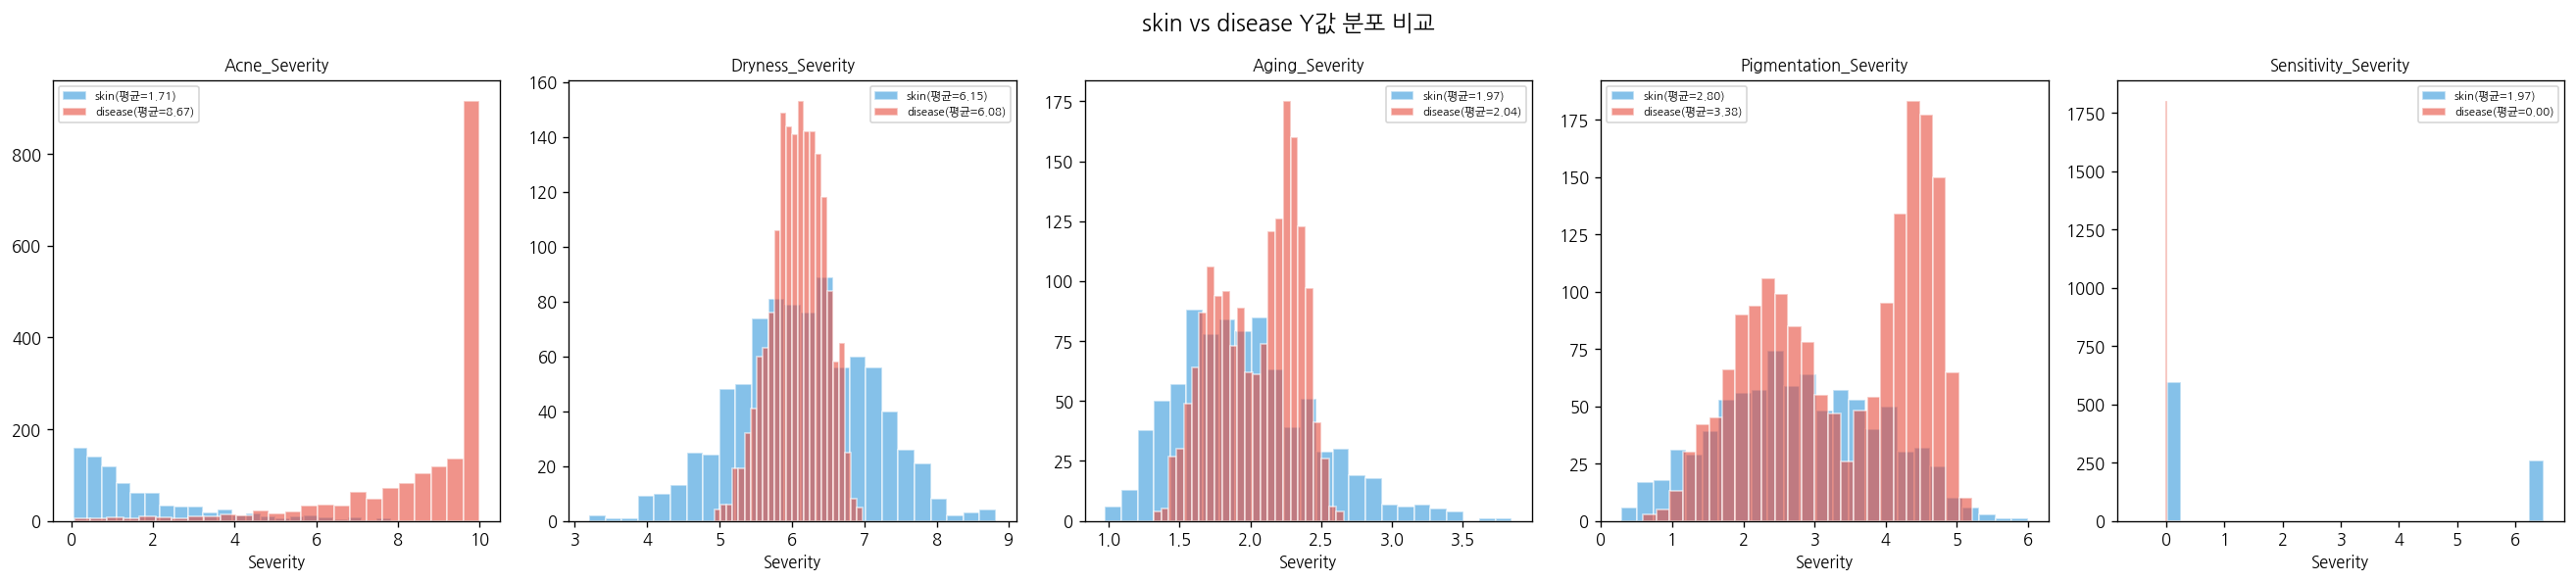

In [11]:
# 4-1. skin vs disease Y값 분포 비교
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(Y_COLS):
    skin_data    = skin_df[col].dropna()
    disease_data = disease_df[col].dropna()
    axes[i].hist(skin_data,    bins=25, alpha=0.6, color='#3498DB',
                 label=f'skin(평균={skin_data.mean():.2f})',    edgecolor='white')
    axes[i].hist(disease_data, bins=25, alpha=0.6, color='#E74C3C',
                 label=f'disease(평균={disease_data.mean():.2f})', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7); axes[i].set_xlabel('Severity')
plt.suptitle('skin vs disease Y값 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/10_skin_vs_disease.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7198/1935431506.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_7198/1935431506.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_7198/1935431506.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_7198/1935431506.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_7198/1935431506.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot

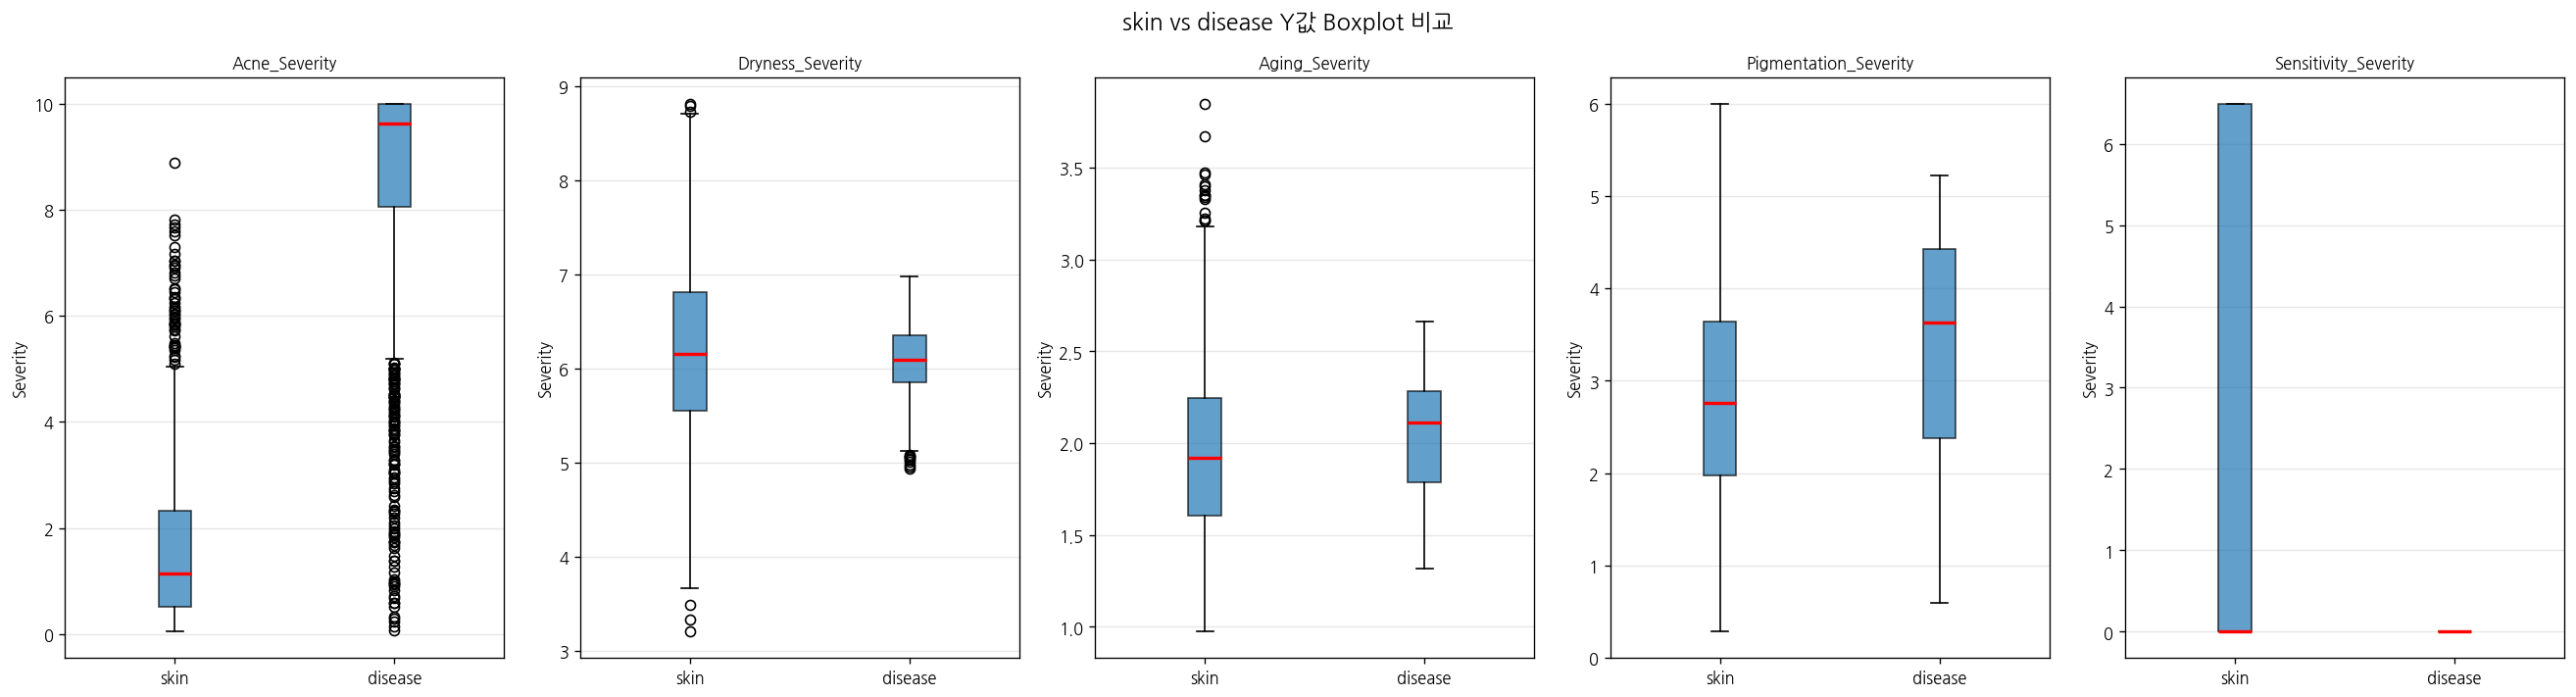

In [12]:
# 4-2. 전체 2658명 Boxplot 비교
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for i, col in enumerate(Y_COLS):
    axes[i].boxplot(
        [skin_df[col].dropna().values, disease_df[col].dropna().values],
        labels=['skin','disease'], patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Severity'); axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('skin vs disease Y값 Boxplot 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR + '/11_skin_vs_disease_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5. 캐글 데이터와 비교

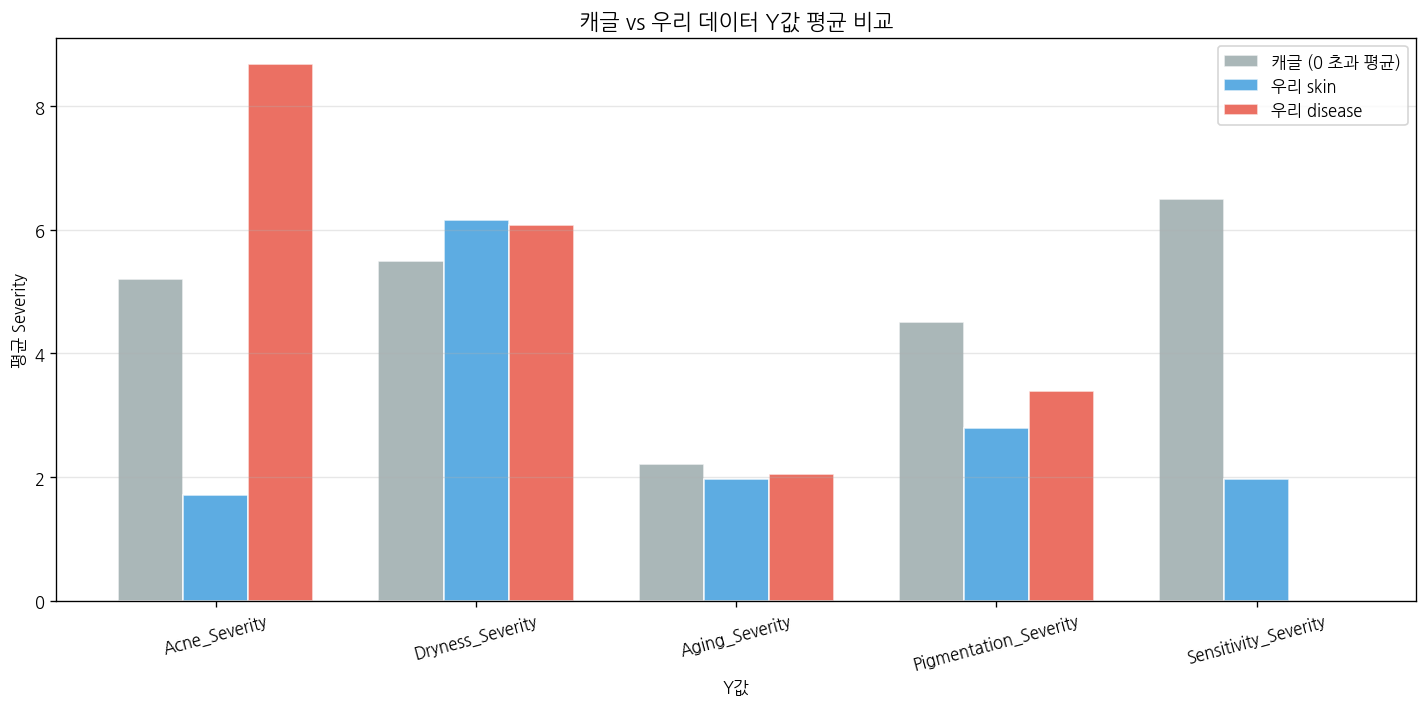

In [13]:
# 캐글 users.csv가 있으면 비교, 없으면 기준값만 표시
KAGGLE_STATS = {
    'Acne_Severity'        : {'mean': 5.21, 'max': 10.0},
    'Dryness_Severity'     : {'mean': 5.50, 'max': 10.0},
    'Aging_Severity'       : {'mean': 2.21, 'max': 4.2},
    'Pigmentation_Severity': {'mean': 4.50, 'max': 6.0},
    'Sensitivity_Severity' : {'mean': 6.49, 'max': 8.0},
}

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(Y_COLS))
width = 0.25

kaggle_means = [KAGGLE_STATS[col]['mean'] for col in Y_COLS]
skin_means   = [skin_df[col].mean() for col in Y_COLS]
disease_means= [disease_df[col].mean() for col in Y_COLS]

ax.bar(x-width, kaggle_means,   width, label='캐글 (0 초과 평균)', color='#95A5A6', alpha=0.8, edgecolor='white')
ax.bar(x,       skin_means,     width, label='우리 skin',          color='#3498DB', alpha=0.8, edgecolor='white')
ax.bar(x+width, disease_means,  width, label='우리 disease',       color='#E74C3C', alpha=0.8, edgecolor='white')

ax.set_title('캐글 vs 우리 데이터 Y값 평균 비교', fontsize=13, fontweight='bold')
ax.set_xlabel('Y값'); ax.set_ylabel('평균 Severity')
ax.set_xticks(x); ax.set_xticklabels(Y_COLS, rotation=15)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_DIR + '/12_kaggle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6. 최종 인사이트 요약

In [14]:
print('=' * 65)
print('COSDUO EDA 최종 인사이트')
print('=' * 65)

print(f'\n[데이터셋 구성]')
print(f'  전체: {len(df)}명')
print(f'  - aihub_skin   : {len(skin_df)}명 (정상 피부 실측 데이터)')
print(f'  - aihub_disease: {len(disease_df)}명 (여드름 환자 이미지)')

print(f'\n[aihub_skin 인구통계]')
print(f'  성별: 남성 {(skin_df["gender_label"]=="남성").sum()}명 / 여성 {(skin_df["gender_label"]=="여성").sum()}명')
print(f'  나이: 평균 {skin_df["age"].mean():.1f}세 (범위: {int(skin_df["age"].min())}~{int(skin_df["age"].max())}세)')

print(f'\n[Y값 통계 - skin]')
print(skin_df[Y_COLS].describe().round(2))

print(f'\n[Y값 통계 - disease]')
print(disease_df[Y_COLS].describe().round(2))

corr = skin_df[Y_COLS].corr()
print(f'\n[주요 인사이트]')
print(f'  1. Aging-Pigmentation 상관관계 높음 (r={corr.loc["Aging_Severity","Pigmentation_Severity"]:.2f})')
print(f'     → 나이 들수록 주름 + 색소침착 동시에 증가')
print(f'  2. Dryness-Aging 음의 상관 (r={corr.loc["Dryness_Severity","Aging_Severity"]:.2f})')
print(f'     → 수분이 높을수록 노화 지표 낮음')
print(f'  3. disease Acne 평균 {disease_df["Acne_Severity"].mean():.2f} >> skin Acne 평균 {skin_df["Acne_Severity"].mean():.2f}')
print(f'     → 여드름 환자 vs 정상인 명확히 구분됨')
print(f'  4. Sensitivity는 이진값(0/6.49) → 이미지 기반 예측 한계 존재')
print(f'  5. 나이 증가할수록 Aging·Pigmentation 수치 증가 확인')
print('=' * 65)
print(f'\nEDA 그래프 저장 위치: {EDA_DIR}')

COSDUO EDA 최종 인사이트

[데이터셋 구성]
  전체: 2658명
  - aihub_skin   : 858명 (정상 피부 실측 데이터)
  - aihub_disease: 1800명 (여드름 환자 이미지)

[aihub_skin 인구통계]
  성별: 남성 430명 / 여성 428명
  나이: 평균 41.5세 (범위: 13~69세)

[Y값 통계 - skin]
       Acne_Severity  Dryness_Severity  Aging_Severity  Pigmentation_Severity  \
count         858.00            858.00          858.00                 858.00   
mean            1.71              6.15            1.97                   2.80   
std             1.65              0.92            0.48                   1.12   
min             0.04              3.20            0.97                   0.28   
25%             0.51              5.55            1.61                   1.97   
50%             1.15              6.15            1.92                   2.76   
75%             2.33              6.82            2.25                   3.64   
max             8.88              8.82            3.85                   6.00   

       Sensitivity_Severity  
count                858.00  
mean